In [2]:
import pandas as pd
 
path = r"C:\Users\Administrator\Desktop\data_learn\Hot-Drink-Retail-Analysis\data\processed\beijing_drink_shops_locationtype_index.csv"

df = pd.read_csv(path, encoding='utf-8')

df['office_count'] = pd.to_numeric(df['office_count'], errors='coerce').fillna(0)
df['park_count'] = pd.to_numeric(df['park_count'], errors='coerce').fillna(0)

df['residential_score'] = (df['office_count'] * 2) - (df['park_count'] * 5)


In [10]:
# 创建占比函数（可复用）
def format_percentage(value, total):
    if total == 0:
        return "0.00%"
    return f"{(value / total * 100):.2f}%"

# 表 1：所有城区的位置类型分布 + 占比
df_table1 = df.groupby('adname')['location_type'].value_counts().unstack(fill_value=0)
df_table1['合计'] = df_table1.sum(axis=1)

# 为每个位置类型计算占比列
for col in df_table1.columns[:-1]:  # 除了"合计"列
    df_table1[f'{col}_占比'] = df_table1.apply(
        lambda row: format_percentage(row[col], row['合计']), 
        axis=1
    )

#display(df_table1)

target_index = ['东城区','西城区','朝阳区']
df_table2 = df_table1.loc[df_table1.index.isin(target_index)]
display(df_table2)


location_type,中庸：混合社区,抗寒：重度商务刚需,脆弱：极度依赖天气,合计,中庸：混合社区_占比,抗寒：重度商务刚需_占比,脆弱：极度依赖天气_占比
adname,,,,,,,
东城区,175,87,2,264,66.29%,32.95%,0.76%
朝阳区,65,29,5,99,65.66%,29.29%,5.05%
西城区,110,21,3,134,82.09%,15.67%,2.24%


In [20]:
# 1. 先标记高分店
THRESHOLD = 50
df['is_high_score'] = df['residential_score'] > THRESHOLD

# 2. 筛选三个目标城区
target_districts = ['东城区', '西城区', '朝阳区']
df_target = df[df['adname'].isin(target_districts)]

# 3. 计算每个城区的高分店数量和总店数
high_score_report = df_target.groupby('adname').agg({
    'is_high_score': ['sum', 'count']  # sum 是高分店数，count 是总店数
})

# 4. 计算占比
high_score_report.columns = ['高分店数', '总店数']
high_score_report['高分店占比(%)'] = (high_score_report['高分店数'] / high_score_report['总店数'] * 100).round(2)

#display(high_score_report[['高分店占比(%)']])
display(high_score_report)

,高分店数,总店数,高分店占比(%)
adname,,,
东城区,19,264,7.20
朝阳区,11,99,11.11
西城区,8,134,5.97


C:\Users\Administrator\AppData\Local\Temp\ipykernel_13604\2551706629.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=target_districts)


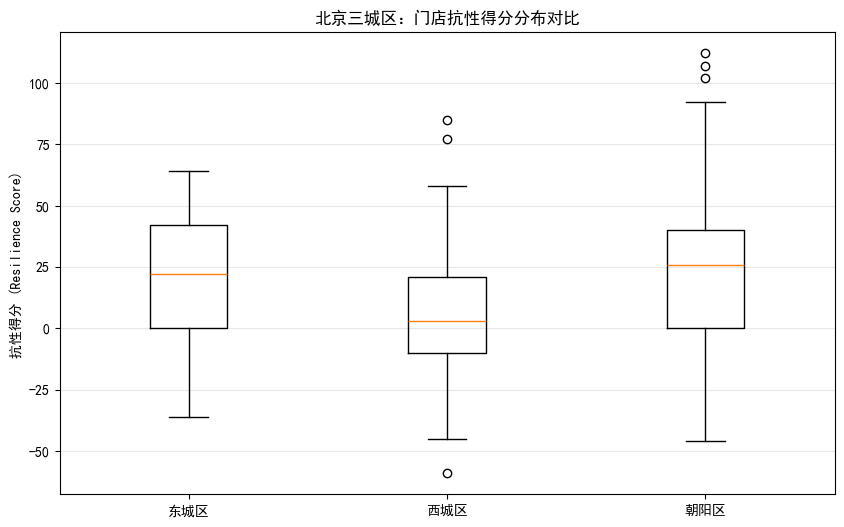

In [23]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 筛选三个城区
target_districts = ['东城区', '西城区', '朝阳区']
df_target = df[df['adname'].isin(target_districts)]

# 准备数据：把三个城区的得分分别放进列表
data_to_plot = [df_target[df_target['adname'] == district]['residential_score'].values 
                for district in target_districts]

# 绘制箱线图
plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot, labels=target_districts)

plt.ylabel('抗性得分 (Resilience Score)')
plt.title('北京三城区：门店抗性得分分布对比')
plt.grid(alpha=0.3, axis='y')
plt.show()

In [24]:
# 计算每个城区的关键指标（用于写结论）
summary = df_target.groupby('adname').agg({
    'office_count': 'mean',      # 平均写字楼数
    'park_count': 'mean',        # 平均公园数
    'residential_score': ['mean', 'median', 'std']  # 得分的均值、中位数、标准差
}).round(2)

display(summary)

office_count park_count residential_score              
               mean       mean              mean median    std
adname                                                        
东城区           13.20       1.02             21.33   22.0  22.00
朝阳区           14.56       1.20             23.10   26.0  29.98
西城区            8.83       2.04              7.47    3.0  24.40